In [110]:
import numpy as np
import rasterio as rio
import geopandas as gpd
from rasterio.enums import Resampling
from rasterstats import zonal_stats  
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
import pandas as pd

In [111]:
path_dhdt_gla = 'data/ele-change-dset-hugonnet/dhdt_mosaic_setp_2000_2019.tif'
path_result_glacier = 'data/ele-change-result/ele_change_glaciers.pkl'
path_rgi60_setp = 'data/land-cover/rgi60/rgi60_setp.shp'
path_setp = 'data/boundary/setp_zhao2022.gpkg'


In [112]:
## read hma and glacier extent
gla_ours = pd.read_pickle(path_result_glacier)
gla_ours = gpd.GeoDataFrame(gla_ours, geometry='geometry')
gla_rgi60_gdf = gpd.read_file(path_rgi60_setp) 
setp_gdf = gpd.read_file(path_setp)
gla_rgi60_gdf.head(3) 


,RGIId,Area,CenLon,CenLat,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,geometry
0,RGI60-13.00607,0.439,94.497482,30.144478,4705,5153,4926,29.7,329,751,"POLYGON ((94.49709 30.14096, 94.49658 30.14077..."
1,RGI60-13.00608,0.056,94.295682,30.045959,5079,5188,5141,24.5,227,261,"POLYGON ((94.29498 30.04706, 94.29556 30.04705..."
2,RGI60-13.00609,0.188,94.294062,30.062443,4837,5086,4920,22.4,42,548,"POLYGON ((94.29346 30.06500, 94.29398 30.06497..."


<Axes: >

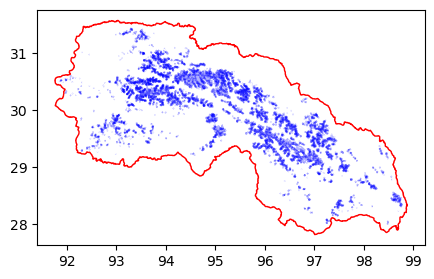

In [113]:
fig, ax = plt.subplots(figsize=(5, 5))
gla_rgi60_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', alpha=0.3)
setp_gdf.plot(ax=ax, facecolor='none', edgecolor='red') 


In [114]:
### read dhdt data
with rio.open(path_dhdt_gla) as src:
    arr_down = src.read(
        1,  # Read the first band
        # out_shape=(src.height // 3, src.width // 3),  # Downsampling
        # resampling=Resampling.bilinear
        )
    src_bounds = src.bounds  # Get the bounds of the source raster
arr_down[arr_down == src.nodata] = np.nan  # Set nodata values to NaN
dhdt_extent = [src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top]


In [115]:
gla_stats = zonal_stats(
    vectors=gla_rgi60_gdf, 
    raster=path_dhdt_gla,   #  path of the raster file
    stats=['mean', 'median', 'std', 'count'],  # statistics to compute
    geojson_out=True,  # output as GeoJSON
    nodata=src.nodata)


In [116]:
gla_stats_gdf = gpd.GeoDataFrame.from_features(gla_stats)
gla_stats_gdf.head(3)

,geometry,RGIId,Area,CenLon,CenLat,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,mean,count,std,median
0,"POLYGON ((94.49709 30.14096, 94.49658 30.14077...",RGI60-13.00607,0.439,94.497482,30.144478,4705,5153,4926,29.7,329,751,-0.935823,34,0.865716,-0.855994
1,"POLYGON ((94.29498 30.04706, 94.29556 30.04705...",RGI60-13.00608,0.056,94.295682,30.045959,5079,5188,5141,24.5,227,261,-1.197647,5,0.813496,-1.064038
2,"POLYGON ((94.29346 30.06500, 94.29398 30.06497...",RGI60-13.00609,0.188,94.294062,30.062443,4837,5086,4920,22.4,42,548,-0.338178,16,1.056039,-0.001648


In [ ]:
gla_stats_gdf_larger4 = gla_stats_gdf[gla_stats_gdf['Area'] > 4]
num_dhdt_larger0 = gla_stats_gdf_larger4[gla_stats_gdf_larger4['mean'] > 0].shape[0]
print(num_dhdt_larger0/301)  # 5.65% when set area threshold to 3  


0.03322259136212625


In [155]:
gla_stats_ours = gla_stats_ours[gla_stats_ours['rate'] < 0.8]
print(gla_stats_gdf_larger4['mean'].mean())
print(gla_stats_ours['rate'].mean()) 


-0.64629542180938
-0.7913430503218378


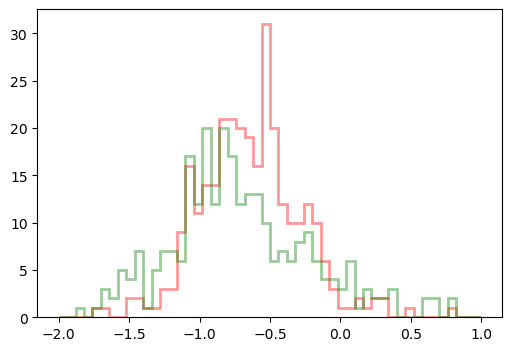

In [160]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gla_stats_gdf_larger4['mean'], 
         bins=50, 
         range=(-2, 1),
         color='skyblue',
         alpha=0.4,
         histtype='step',         
         edgecolor='red',
         lw = 2);
ax.hist(gla_stats_ours['rate'], 
         bins=50, 
         range=(-2, 1),
         color='salmon', 
         histtype='step',
         lw = 2, 
         edgecolor='green', 
         alpha=0.4);



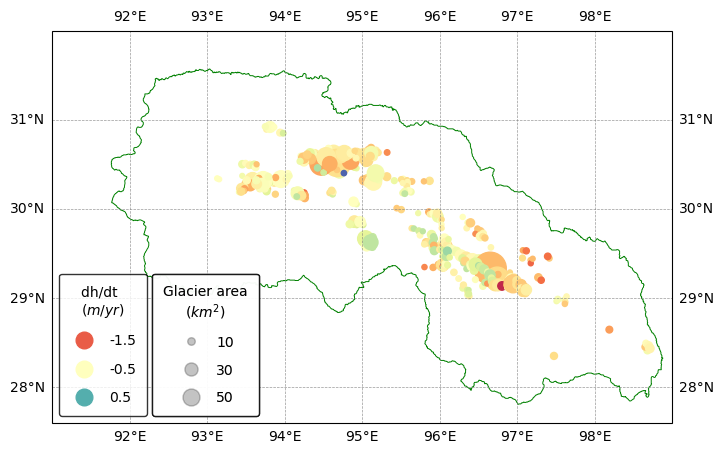

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([91, 99, 27.6, 32])
## 1. Tibeteau southeast boundary
setp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', lw=0.7)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.8, zorder=1, color='grey', linestyle='--')

size_scale = 3
scatter = ax.scatter(
    x = gla_stats_gdf_larger1['geometry'].centroid.x,
    y = gla_stats_gdf_larger1['geometry'].centroid.y,
    s = gla_stats_gdf_larger1['Area']*size_scale,
    c = gla_stats_gdf_larger1['median'].values,
    cmap = 'Spectral',
    alpha=1, 
    linewidth=1,
    vmin=-2,
    vmax=1,
    transform=ccrs.PlateCarree(),
    )

# produce a legend with the unique colors from the scatter
handles, labels = scatter.legend_elements(prop="colors", num=[-1.5,-0.5,0.5], fmt="{x:.1f}")
legend_color = ax.legend(handles, labels, loc="lower left", title="dh/dt \n($m/yr$)",\
                        facecolor='white', edgecolor='black', borderpad=0.8, labelspacing=1.05, markerscale=2)

# produce a legend with a cross-section of sizes from the scatter
handles_, labels_ = scatter.legend_elements(prop="sizes", \
                            num=[10*size_scale, 30*size_scale, 50*size_scale], alpha=0.2)
legend_size = ax.legend(handles_, [10, 30, 50], loc="lower left", title="Glacier area\n     (${km^2}$)", \
                            edgecolor='black', borderpad = 0.8, labelspacing=1., bbox_to_anchor=(0.15, 0.))
_ = ax.add_artist(legend_color)
_ = ax.add_artist(legend_size) 

